In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# ── IMPORTS ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Bidirectional,
                                     LSTM, Dense, Dropout, Flatten)
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✅")
print("TensorFlow version:", tf.__version__)

All libraries loaded ✅
TensorFlow version: 2.20.0


In [24]:
#loading gold files -> csv to pandas

path = '/content/drive/MyDrive/mlprojects/GoldUSD.csv'

df = pd.read_csv(path)


# Parse date and sort
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print("Shape:", df.shape)
print(df.head())
print(df.tail())

Shape: (6399, 6)
        Date        Open        High         Low       Close  Volume
0 2000-08-30  273.899994  273.899994  273.899994  273.899994       0
1 2000-08-31  274.799988  278.299988  274.799988  278.299988       0
2 2000-09-01  277.000000  277.000000  277.000000  277.000000       0
3 2000-09-05  275.799988  275.799988  275.799988  275.799988       2
4 2000-09-06  274.200012  274.200012  274.200012  274.200012       0
           Date         Open         High          Low        Close  Volume
6394 2026-02-25  5166.000000  5206.399902  5166.000000  5206.399902    1772
6395 2026-02-26  5177.200195  5199.200195  5143.899902  5176.500000    1520
6396 2026-02-27  5186.700195  5280.000000  5176.700195  5230.500000     354
6397 2026-03-02  5346.600098  5405.000000  5266.299805  5294.399902     354
6398 2026-03-03  5335.700195  5394.200195  5334.899902  5377.299805   21189


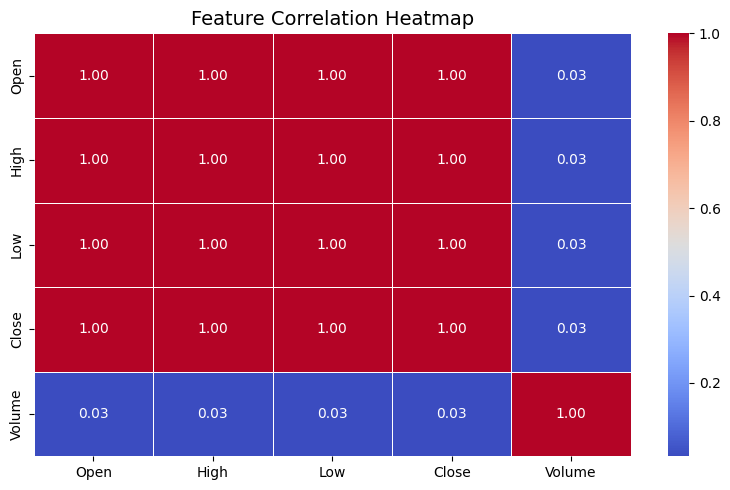

In [25]:
# ── VISUALIZATION 1: CORRELATION HEATMAP ─────────────────────────────────
plt.figure(figsize=(8, 5))
corr = df[['Open','High','Low','Close','Volume']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

In [26]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────
df['MA7']  = df['Close'].rolling(window=7).mean()
df['MA30'] = df['Close'].rolling(window=30).mean()

# Drop NaN rows created by rolling windows
df = df.dropna().reset_index(drop=True)

print("After adding MAs, shape:", df.shape)

After adding MAs, shape: (6370, 8)


In [27]:
correlation = df.corr(numeric_only=True)

<Axes: >

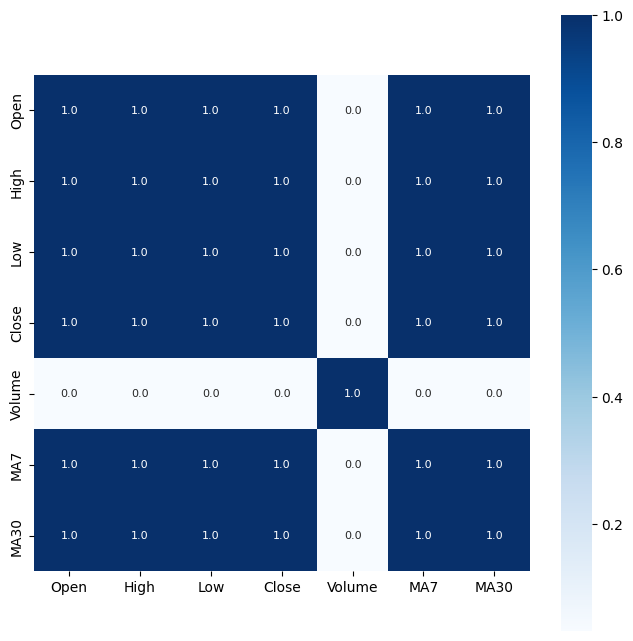

In [28]:
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')


In [29]:
X = df.drop(['Date', 'Close'], axis = 1)
Y = df['Close']


In [30]:
print(X)

             Open         High          Low  Volume          MA7         MA30
0      272.500000   273.500000   270.500000      18   270.685713   272.929997
1      274.000000   276.399994   274.000000       3   271.371425   273.013330
2      274.200012   274.200012   272.399994       0   271.671426   272.816664
3      271.500000   271.500000   271.500000       5   271.799997   272.633330
4      271.100006   271.100006   271.100006       0   272.057142   272.476664
...           ...          ...          ...     ...          ...          ...
6365  5166.000000  5206.399902  5166.000000    1772  5067.357073  4939.759977
6366  5177.200195  5199.200195  5143.899902    1520  5109.299944  4959.336637
6367  5186.700195  5280.000000  5176.700195     354  5144.157087  4979.476644
6368  5346.600098  5405.000000  5266.299805     354  5189.657087  5002.079980
6369  5335.700195  5394.200195  5334.899902   21189  5235.085658  5028.376644

[6370 rows x 6 columns]


In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state=45)

In [32]:
regressor = RandomForestRegressor(n_estimators=100)

In [33]:
regressor.fit(X_train, Y_train)

RandomForestRegressor()

In [34]:
test_data_prediction = regressor.predict(X_test)

In [35]:
print(test_data_prediction)

[1223.058009   1229.38201034 3342.17599853 ... 1675.85400874 1559.02102669
 1117.10900392]


In [36]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────
#avg for 7 days to analyse short term trend and then 30 for long term trend
df['MA7']  = df['Close'].rolling(window=7).mean()
df['MA30'] = df['Close'].rolling(window=30).mean()

# Drop NaN rows created by rolling windows
df = df.dropna().reset_index(drop=True)

print("After adding MAs, shape:", df.shape)

After adding MAs, shape: (6341, 8)


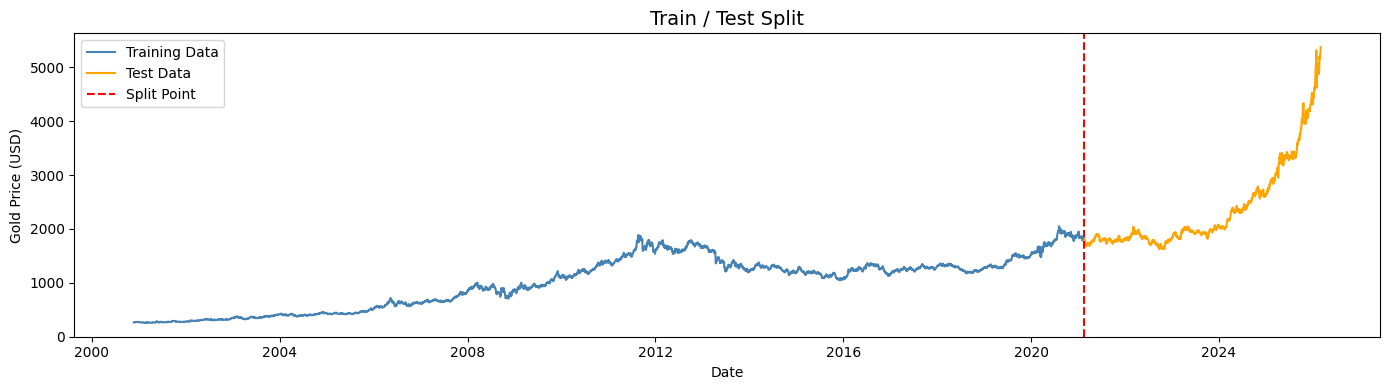

In [37]:
# ── VISUALIZATION 2: TRAIN/TEST SPLIT ────────────────────────────────────
split_idx = int(len(df) * 0.8)

plt.figure(figsize=(14, 4))
plt.plot(df['Date'][:split_idx], df['Close'][:split_idx],
         label='Training Data', color='steelblue')
plt.plot(df['Date'][split_idx:], df['Close'][split_idx:],
         label='Test Data', color='orange')
plt.axvline(df['Date'][split_idx], color='red', linestyle='--', label='Split Point')
plt.title('Train / Test Split', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Gold Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150)
plt.show()

In [38]:
# ── SCALING ───────────────────────────────────────────────────────────────
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA30']
target   = 'Close'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_all = df[features].values
y_all = df[[target]].values

X_scaled = scaler_X.fit_transform(X_all)
y_scaled = scaler_y.fit_transform(y_all)

# Train/test split (80/20, time-ordered — no shuffling!)
split = int(len(X_scaled) * 0.8)

X_train_sc = X_scaled[:split]
X_test_sc  = X_scaled[split:]
y_train_sc = y_scaled[:split]
y_test_sc  = y_scaled[split:]

# Also keep unscaled for baseline ML models
X_train_ml = X_all[:split]
X_test_ml  = X_all[split:]
y_train_ml = y_all[:split].ravel()
y_test_ml  = y_all[split:].ravel()

print("Train size:", X_train_sc.shape, "| Test size:", X_test_sc.shape)

Train size: (5072, 7) | Test size: (1269, 7)


In [40]:
# ── HELPER: EVALUATE ANY MODEL ────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.4f}%")
    return {'Model': name, 'RMSE': round(rmse,2),
            'MAE': round(mae,2), 'R2': round(r2,4), 'MAPE': round(mape,2)}

results = []  # we'll collect all model scores here

# ── LINEAR REGRESSION ─────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_ml, y_train_ml)
lr_pred = lr.predict(X_test_ml)
results.append(evaluate("Linear Regression", y_test_ml, lr_pred))

# ── RANDOM FOREST ─────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=45)
rf.fit(X_train_ml, y_train_ml)
rf_pred = rf.predict(X_test_ml)
results.append(evaluate("Random Forest", y_test_ml, rf_pred))

# ── XGBOOST ───────────────────────────────────────────────────────────────
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05,
                   max_depth=6, random_state=45)
xgb.fit(X_train_ml, y_train_ml)
xgb_pred = xgb.predict(X_test_ml)
results.append(evaluate("XGBoost", y_test_ml, xgb_pred))


  Linear Regression
  RMSE : 0.0000
  MAE  : 0.0000
  R²   : 1.0000
  MAPE : 0.0000%

  Random Forest
  RMSE : 861.2461
  MAE  : 443.9648
  R²   : -0.1302
  MAPE : 12.6367%

  XGBoost
  RMSE : 899.9294
  MAE  : 479.4238
  R²   : -0.2340
  MAPE : 13.9300%


In [42]:
# ── CREATE SEQUENCES FOR DEEP LEARNING ───────────────────────────────────
# The model looks at the last 60 days to predict the next day
SEQ_LEN = 60

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_tr_seq, y_tr_seq = make_sequences(X_train_sc, y_train_sc, SEQ_LEN)
X_te_seq, y_te_seq = make_sequences(X_test_sc,  y_test_sc,  SEQ_LEN)

print("Sequence shapes — Train:", X_tr_seq.shape, "| Test:", X_te_seq.shape)

Sequence shapes — Train: (5012, 60, 7) | Test: (1209, 60, 7)


In [44]:
# ── CNN + Bi-LSTM MODEL ───────────────────────────────────────────────────
tf.random.set_seed(42)

model = Sequential([
    # CNN block — extracts local patterns
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(SEQ_LEN, X_tr_seq.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Bi-LSTM block — captures long-range time dependencies
    Bidirectional(LSTM(100, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(50, return_sequences=False)),
    Dropout(0.2),

    # Output
    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ── TRAIN ─────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True)

history = model.fit(
    X_tr_seq, y_tr_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 58, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 29, 200)        │       132,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 29, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,359 (923.28 KB)

 Trainable params: 236,359 (923.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 96ms/step - loss: 6.9492e-04 - mae: 0.0158 - val_loss: 4.7625e-04 - val_mae: 0.0188
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - loss: 2.2221e-04 - mae: 0.0107 - val_loss: 5.6455e-04 - val_mae: 0.0211
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 1.8948e-04 - mae: 0.0099 - val_loss: 2.4344e-04 - val_mae: 0.0127
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - loss: 1.4497e-04 - mae: 0.0085 - val_loss: 1.6498e-04 - val_mae: 0.0100
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - loss: 1.4548e-04 - mae: 0.0087 - val_loss: 4.3719e-04 - val_mae: 0.0189
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 1.1597e-04 - mae: 0.0078 - val_loss: 3.1611e-04 - val_mae: 0.0156
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - loss: 1.1580e-04 - mae: 0.0079 - val_loss: 3.1892e-04 - val_mae: 0.0160
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 9.8219e-05 - mae: 0.0072 - val_los

In [45]:
# ── PREDICT & INVERSE SCALE ───────────────────────────────────────────────
dl_pred_scaled = model.predict(X_te_seq)
dl_pred = scaler_y.inverse_transform(dl_pred_scaled).ravel()
y_test_actual = scaler_y.inverse_transform(y_te_seq).ravel()

results.append(evaluate("CNN + Bi-LSTM", y_test_actual, dl_pred))

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step

  CNN + Bi-LSTM
  RMSE : 182.9564
  MAE  : 107.5609
  R²   : 0.9500
  MAPE : 3.4896%


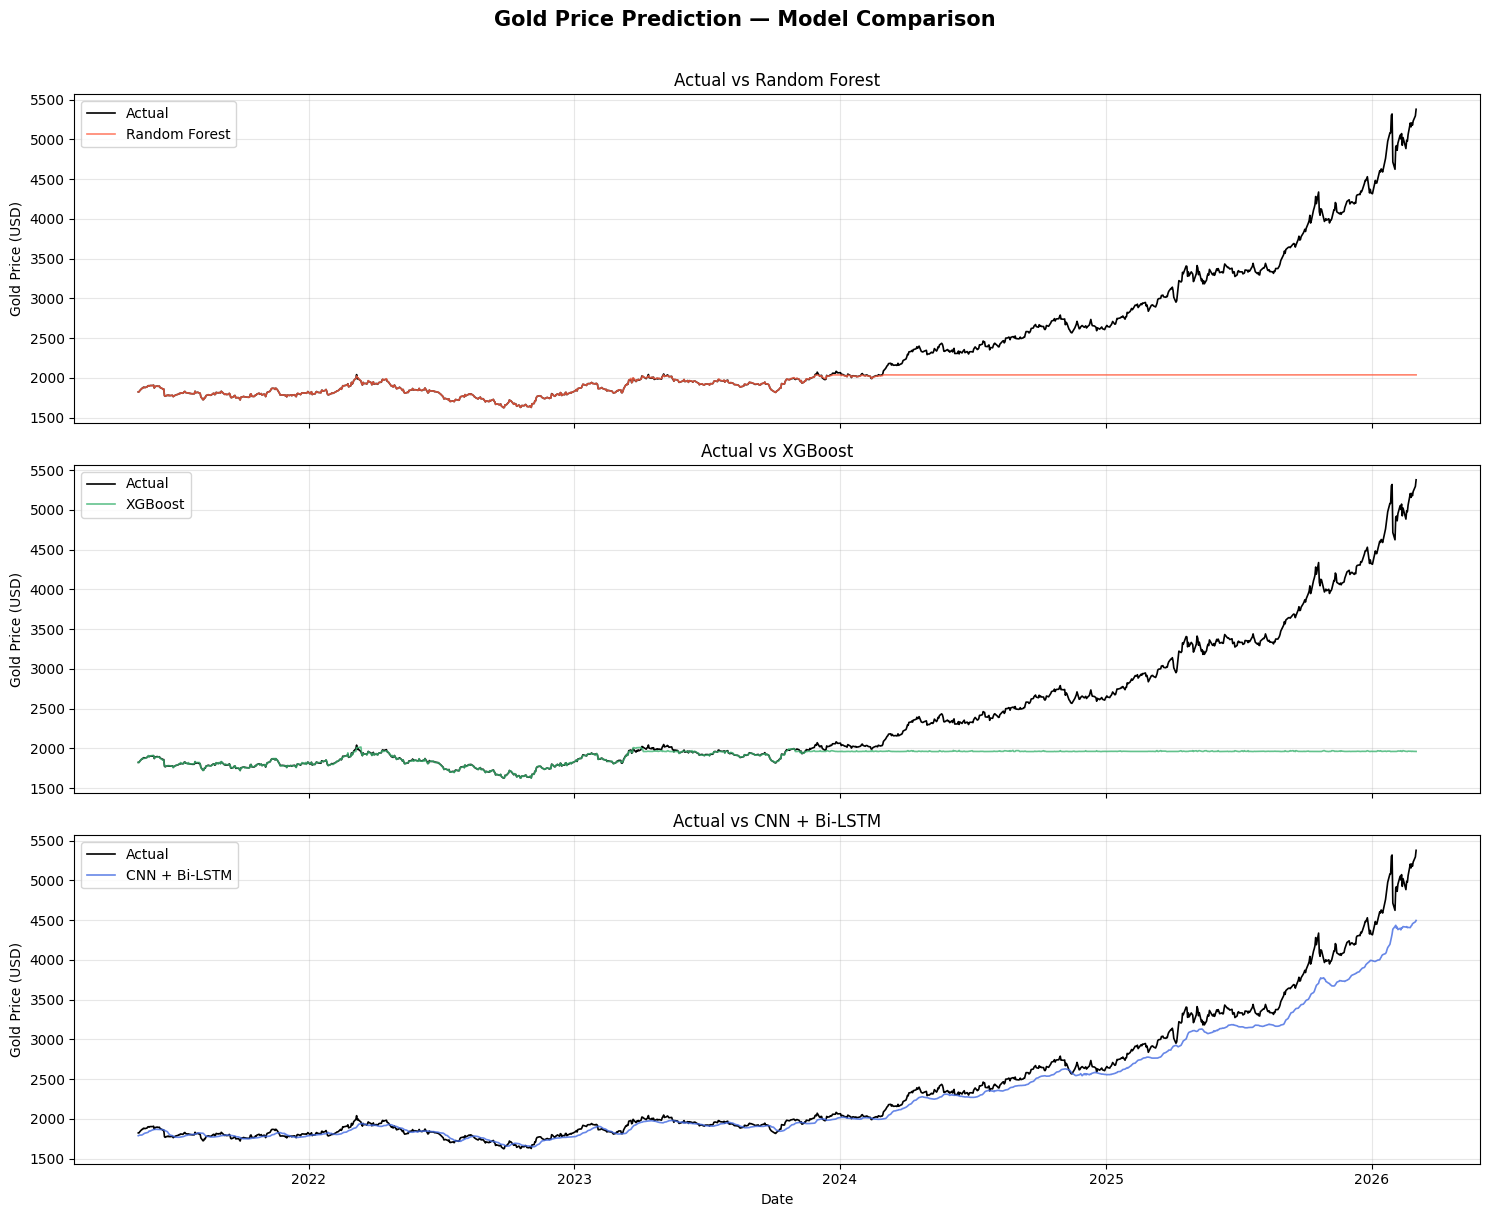

In [46]:
# ── VISUALIZATION 3: ACTUAL VS PREDICTED ─────────────────────────────────
# Align baseline predictions to same test window as deep learning
# (deep learning loses first SEQ_LEN points due to sequence creation)
offset = SEQ_LEN
test_dates = df['Date'].values[split + offset:]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
preds  = [rf_pred[offset:], xgb_pred[offset:], dl_pred]
names  = ['Random Forest', 'XGBoost', 'CNN + Bi-LSTM']
colors = ['tomato', 'mediumseagreen', 'royalblue']

for ax, pred, name, color in zip(axes, preds, names, colors):
    ax.plot(test_dates, y_test_actual, label='Actual',
            color='black', linewidth=1.2)
    ax.plot(test_dates, pred, label=name,
            color=color, linewidth=1.2, alpha=0.8)
    ax.set_title(f'Actual vs {name}', fontsize=12)
    ax.set_ylabel('Gold Price (USD)')
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('Gold Price Prediction — Model Comparison',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

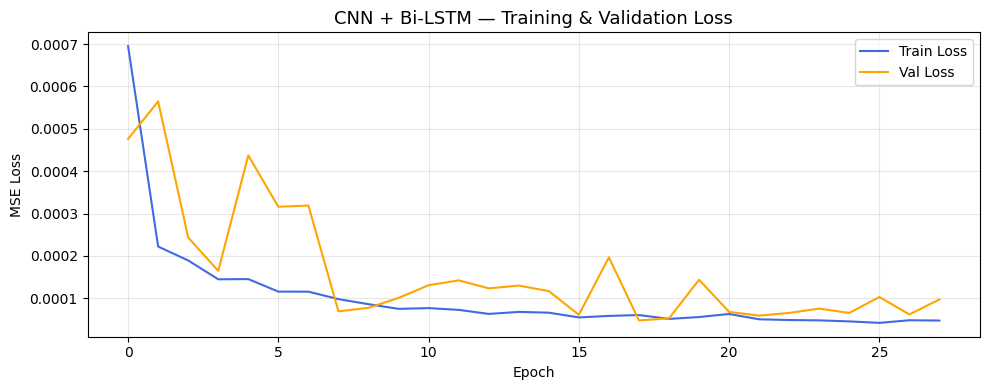

In [47]:
# ── VISUALIZATION 4: TRAINING LOSS CURVES ────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='royalblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')
plt.title('CNN + Bi-LSTM — Training & Validation Loss', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()


📊 MODEL COMPARISON TABLE
            Model   RMSE    MAE      R2  MAPE
Linear Regression   0.00   0.00  1.0000  0.00
    CNN + Bi-LSTM 182.96 107.56  0.9500  3.49
    Random Forest 861.25 443.96 -0.1302 12.64
          XGBoost 899.93 479.42 -0.2340 13.93


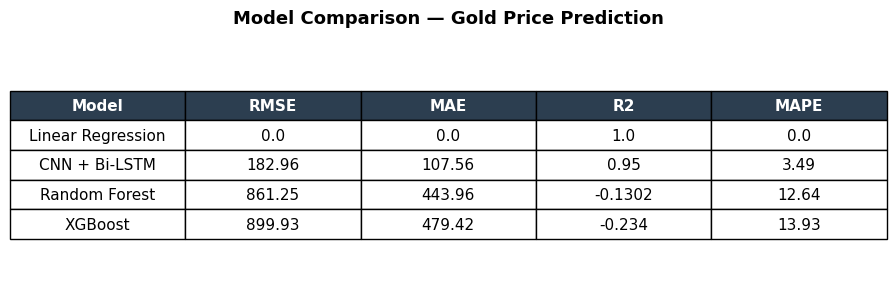

In [48]:
# ── FINAL COMPARISON TABLE ────────────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')
print("\n📊 MODEL COMPARISON TABLE")
print(results_df.to_string(index=False))

# Visualize it
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')
table = ax.table(cellText=results_df.values, colLabels=results_df.columns,
                 cellLoc='center', loc='center',
                 colColours=['#2c3e50']*len(results_df.columns))
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(color='white', fontweight='bold')
plt.title('Model Comparison — Gold Price Prediction',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
import joblib

# Save the trained model
model.save('cnn_bilstm_gold.h5')

# Save both scalers
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

# Save the processed dataframe (with MAs)
df.to_csv('GoldUSD_processed.csv', index=False)

print("✅ All files saved!")

✅ All files saved!
